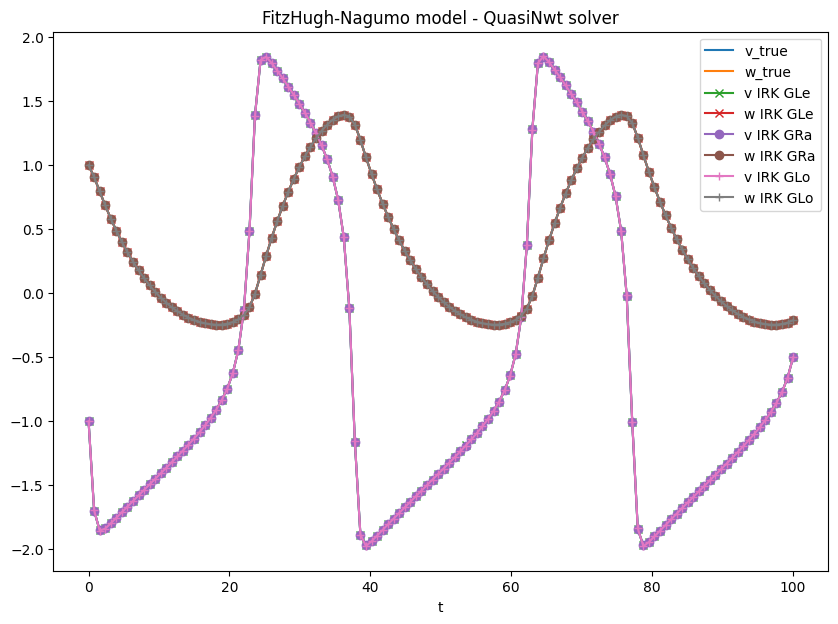

In [ ]:
import numpy as np
from meth2_I import IRK3_solver, impl_euler,impl_euler_quasi, impl_CN, impl_CN_quasi
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp, BDF, RK23


I = 0.5
def f(t, y):
    v, w = y
    return np.array([v - v**3/3 - w + I,
                     0.08*(v + 0.7 - 0.8*w)])

def J(t, y):
    v, w = y
    return np.array([[1 - v**2, -1.0],
                     [0.08, -0.064]])

t0 = 0.0
y0 = np.array([-1.0, 1.0])
T = 100
N = 128

T_span=(t0,T)

meth='QuasiNwt'
t1,Y1,feval1=impl_euler_quasi(f, T_span,y0,N, tau=1e-6, maxit=1000)
t3,Y3,feval3=impl_CN_quasi(f, T_span,y0,N, tau=1e-6, maxit=1000)
t4,Y4,feval4=IRK3_solver(f, J, y0, T_span,N,  'GLe', meth)
t5,Y5,feval5=IRK3_solver(f, J, y0, T_span,N,  'GRa', meth)
t6,Y6,feval6=IRK3_solver(f, J, y0, T_span,N,  'GLo', meth)


def ode(t, y):
    v, w = y
    return np.array([v - v**3/3 - w + I,
                     0.08*(v + 0.7 - 0.8*w)])

t=t1
sol_ivp = solve_ivp(ode, T_span, y0, t_eval=t, rtol=1e-9, atol=1e-12)
y_true = sol_ivp.y.ravel()

plt.figure(figsize=(10,7))
plt.plot(t, y_true[:N], label='v_true')
plt.plot(t, y_true[N:], label='w_true')
plot_expl_euler=0
if plot_expl_euler==1:
    #plt.plot(t, Y[0,:], 'o-',label='v impl_euler')
    #plt.plot(t, Y[1,:], 'o-',label='w impl_euler')
    plt.plot(t1, Y1[0,:], 's-',label='v impl_euler_quasi')
    plt.plot(t1, Y1[1,:], 's-',label='w impl_euler_quasi')
plot_CN=0
if plot_CN==1:   
    #plt.plot(t2, Y2[0,:], '^-',label='v C-N')
    #plt.plot(t2, Y2[1,:], '^-',label='w C-N')
    plt.plot(t3, Y3[0,:], 'D-',label='v C-N_quasi')
    plt.plot(t3, Y3[1,:], 'D-',label='w C-N_quasi')
plot_IRK=1
if plot_IRK==1:
    plt.plot(t4, Y4[0,:], 'x-',label='v IRK GLe')
    plt.plot(t4, Y4[1,:], 'x-',label='w IRK GLe')
    plt.plot(t5, Y5[0,:], 'o-',label='v IRK GRa')
    plt.plot(t5, Y5[1,:], 'o-',label='w IRK GRa')
    plt.plot(t6, Y6[0,:], '+-',label='v IRK GLo')
    plt.plot(t6, Y6[1,:], '+-',label='w IRK GLo')

plt.title('FitzHugh-Nagumo model - '+meth+' solver')
plt.xlabel('t')
plt.legend()
plt.show()

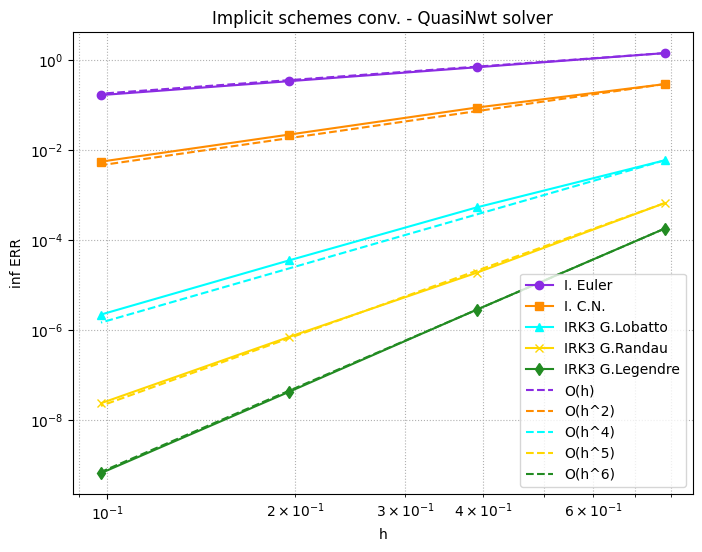

In [ ]:
Ns = [2**k for k in range(7, 11)]  
hs = []
errs_eq = []
errs_cnq = []
errs_gle = []
errs_gra = []
errs_glo = []
fevals = []

for N in Ns:
    tnum, sol_e, fe_e = impl_euler_quasi(f, T_span, y0, N, tau=1e-6, maxit=1000)
    tnum, sol_cn, fe_cn = impl_CN_quasi(f, T_span, y0, N, tau=1e-6, maxit=1000)
    tnum, sol_gle, fe_gle = IRK3_solver(f, J, y0, T_span, N, 'GLe', 'QuasiNwt')
    tnum, sol_gra, fe_gra = IRK3_solver(f, J, y0, T_span, N, 'GRa', 'QuasiNwt')
    tnum, sol_glo, fe_glo = IRK3_solver(f, J, y0, T_span, N, 'GLo', 'QuasiNwt')

    sol_ivp_local = solve_ivp(ode, T_span, y0, t_eval=tnum, rtol=1e-12, atol=1e-14)
    y_true_local = sol_ivp_local.y.ravel()

    
    err_e = np.nanmax(np.abs(sol_e.ravel() - y_true_local))
    err_cn = np.nanmax(np.abs(sol_cn.ravel() - y_true_local))
    err_gle = np.nanmax(np.abs(sol_gle.ravel() - y_true_local))
    err_gra = np.nanmax(np.abs(sol_gra.ravel() - y_true_local))
    err_glo = np.nanmax(np.abs(sol_glo.ravel() - y_true_local))

    h = (T_span[1] - T_span[0]) / N

    hs.append(h)
    errs_eq.append(err_e)
    errs_cnq.append(err_cn)
    errs_gle.append(err_gle)
    errs_gra.append(err_gra)
    errs_glo.append(err_glo)
    fevals.append((fe_e, fe_cn, fe_gle, fe_gra, fe_glo))

hs = np.array(hs)
errs_eq = np.array(errs_eq)
errs_cnq = np.array(errs_cnq)
errs_gle = np.array(errs_gle)
errs_gra = np.array(errs_gra)
errs_glo = np.array(errs_glo)

plt.figure(figsize=(8,6))
plt.loglog(hs, errs_eq, 'o-', color='blueviolet', label='I. Euler')
plt.loglog(hs, errs_cnq, 's-', color='darkorange', label='I. C.N.')
plt.loglog(hs, errs_glo, '^-', color='cyan', label='IRK3 G.Lobatto')
plt.loglog(hs, errs_gra, 'x-', color='gold', label='IRK3 G.Randau')
plt.loglog(hs, errs_gle, 'd-', color='forestgreen', label='IRK3 G.Legendre')

ref1 = errs_eq[0] / (hs[0]**1) * hs**1
ref2 = errs_cnq[0] / (hs[0]**2) * hs**2
ref3 = errs_glo[0] / (hs[0]**4) * hs**4
ref4 = errs_gra[0] / (hs[0]**5) * hs**5 
ref5 = errs_gle[0] / (hs[0]**6) * hs**6
plt.loglog(hs, ref1, '--', color='blueviolet', label='O(h)')
plt.loglog(hs, ref2, '--', color='darkorange', label='O(h^2)')
plt.loglog(hs, ref3, '--', color='cyan', label='O(h^4)')
plt.loglog(hs, ref4, '--', color='gold', label='O(h^5)')
plt.loglog(hs, ref5, '--', color='forestgreen', label='O(h^6)')

plt.xlabel('h'); plt.ylabel('inf ERR'); plt.grid(True, which='both', ls=':'); plt.legend(); 
plt.title("Implicit schemes conv. - "+meth+" solver")
plt.show()

In [ ]:
print(f"{'N':6s} {'h':12s} {'f_ev_IEuler':12s} {'f_ev_CN':12s} {'f_ev_IRK3GLo':12s} {'f_ev_IRK3GRa':12s} {'f_ev_IRK3GLe':12s}")
for i,N in enumerate(Ns):
    print(f"{N:6d} {hs[i]:12.3e} {fevals[i][0]:12.3e} {fevals[i][1]:12.3e} {fevals[i][2]:12.3e} {fevals[i][3]:12.3e} {fevals[i][4]:12.3e}")

N      h            f_ev_IEuler  f_ev_CN      f_ev_IRK3GLo f_ev_IRK3GRa f_ev_IRK3GLe
   128    7.812e-01    4.660e+02    4.360e+02    3.560e+02    3.570e+02    3.560e+02
   256    3.906e-01    8.160e+02    7.850e+02    6.350e+02    6.500e+02    6.420e+02
   512    1.953e-01    1.557e+03    1.545e+03    1.193e+03    1.207e+03    1.190e+03
  1024    9.766e-02    3.038e+03    3.023e+03    2.210e+03    2.210e+03    2.270e+03


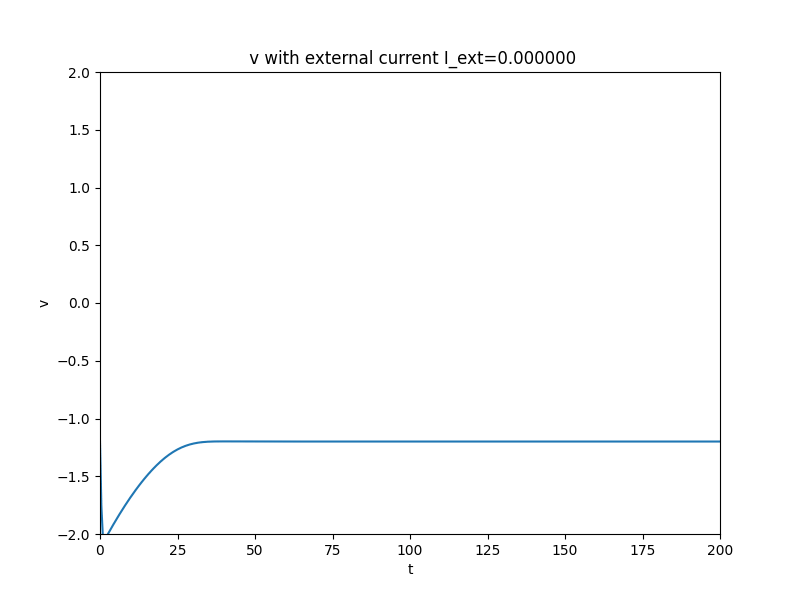

In [ ]:
from matplotlib.animation import FuncAnimation,PillowWriter
from IPython.display import Image

current=[]
Y_full=[]
t_steps=70
for I in np.linspace(0,0.4,t_steps):
    def f(t, y):
        v, w = y
        return np.array([v - v**3/3 - w + I,
                        0.08*(v + 0.7 - 0.8*w)])

    def J(t, y):
        v, w = y
        return np.array([[1 - v**2, -1.0],
                        [0.08, -0.064]])

    t0 = 0.0
    y0 = np.array([-1.2, 1.0])
    T = 200
    N = 450

    T_span=(t0,T)

    t4,Y4,feval4=impl_CN_quasi(f, T_span, y0, N, tau=1e-6, maxit=1000)

    current.append(I)
    Y_full.append(Y4)

showSomePlots=False
if showSomePlots:
        for ind in [0,5,10,15,19]:
                plt.figure(figsize=(8,6))
                plt.plot(t4, Y_full[ind][0])
                plt.xlabel("t")
                plt.ylabel("v")
                plt.title(f" v with external current I_ext={current[ind]}")
                plt.legend()
                plt.show()

createAnimation=True
if createAnimation:
    fig, ax = plt.subplots(figsize=(8,6))
    line, = ax.plot(t4, Y_full[0][0])
    ax.set_xlabel("t"); ax.set_ylabel("v")
    ax.set_xlim(t4.min(), t4.max())
    ax.set_ylim(-2,2)

    def update(i):
        line.set_ydata(Y_full[i][0])
        ax.set_title(f" v with external current I_ext={current[i]:1f}")
        return (line,)

    anim = FuncAnimation(fig, update, frames=range(t_steps), interval=30)
    anim.save("hopfbif.gif", writer=PillowWriter(fps=20))
    plt.close(fig)

#show the animation 
Image("hopfbif.gif")


In [ ]:
# Robertson stiff chemical kinetics 
testSTIFFprob=1
if testSTIFFprob:
    from scipy.integrate import solve_ivp
    import numpy as np
    import matplotlib.pyplot as plt
    import time
    import tracemalloc
    import warnings
    warnings.simplefilter("ignore")

    def f_rob(t, y):
        return np.array([
            -0.04*y[0] + 1e4*y[1]*y[2],
            0.04*y[0] - 1e4*y[1]*y[2] - 3e7*y[1]**2,
            3e7*y[1]**2
        ])

    def J_rob(t,y):
        return np.array([
            [-0.04,1e4*y[2],1e4*y[1]],
            [0.04,-1e4*y[2]-6e7*y[1],-1e4*y[1]],
            [0,6e7*y[1],0]
            ])


    y0_rob     = np.array([1.0, 0.0, 0.0])
    T_span_rob = (int(0), int(1e5))

    methods = ['RK23','RK45','DOP853']
    Tf=[10] # 100 -> take approx. 2:30 minutes

    results = []
    for tfin in Tf:
        T_span_rob = (int(0),tfin)
        for meth in methods:
            t_start = time.perf_counter()
            tracemalloc.start()
            sol = solve_ivp(f_rob, T_span_rob, y0_rob, method=meth, #t_eval=t_eval_b,
                        rtol=1e-6, atol=1e-9, dense_output=False)
            runtime = time.perf_counter() - t_start
            feval = sol.nfev
            peak_bytes = max(tracemalloc.get_traced_memory())
            tracemalloc.stop()

            results.append((meth,tfin, runtime, feval, peak_bytes / 1024, sol.success))

    col = [10, 16, 10, 16, 9]
    header = (f"{'Method':<{col[0]}}{'Final time':>{col[4]}} {'Runtime (s)':>{col[1]}} {'feval':>{col[2]}}{'Peak mem (KB)':>{col[3]}} {'Success':>{col[4]}}")
    sep = "-" * 2*sum(col)
    print(header)
    print(sep)
    for meth,tfin, rt, fe, mem, ok in results:
        print(f"{meth:<{col[0]}} {tfin:>{col[4]}}{rt:>{col[1]}.4f} {fe:>{col[2]}} {mem:>{col[3]}.1f} {str(ok):>{col[4]}}")
    print(sep)



    methods = ['LSODA','Radau', 'BDF']
    Tf=[int(1e9)]

    results = []
    for tfin in Tf:
        T_span_rob = (int(0),tfin)
        for meth in methods:
            t_start = time.perf_counter()
            tracemalloc.start()
            sol = solve_ivp(f_rob, T_span_rob, y0_rob, method=meth, #t_eval=t_eval_b,
                        rtol=1e-6, atol=1e-9, dense_output=False)
            runtime = time.perf_counter() - t_start
            feval = sol.nfev
            peak_bytes = max(tracemalloc.get_traced_memory())
            tracemalloc.stop()

            results.append((meth,tfin, runtime, feval, peak_bytes / 1024, sol.success))

    for meth,tfin, rt, fe, mem, ok in results:
        print(f"{meth:<{col[0]}} {tfin:>{col[4]}}{rt:>{col[1]}.4f} {fe:>{col[2]}} {mem:>{col[3]}.1f} {str(ok):>{col[4]}}")
    print(sep)

Method    Final time      Runtime (s)      feval   Peak mem (KB)   Success
--------------------------------------------------------------------------------------------------------------------------
RK23              10          2.4899      28070           2997.3      True
RK45              10          2.9518      49964           2276.9      True
DOP853            10          2.2139      44114           1184.3      True
--------------------------------------------------------------------------------------------------------------------------
LSODA      1000000000          0.0461       1284            233.3      True
Radau      1000000000          0.4393       2324            117.7      True
BDF        1000000000          0.3667       1482            177.7      True
--------------------------------------------------------------------------------------------------------------------------
